# 📊 전략 백테스팅

**전제:** `01~04 노트북` 실행 완료 후 실행

기술적 지표 기반 매매 전략이 실제로 수익이 났는지 검증한다.

| 전략 | 설명 |
|------|------|
| 단순 보유 | 2019년 1월 매수 후 5년 보유 |
| 기술적 전략 | RSI + MACD + 볼린저밴드 다수결 신호 |
| 포트폴리오 | 대형주 10종목 동일 비중 분산 투자 vs 코스피 |

**평가 지표:** 총수익률, CAGR, 샤프비율, 최대낙폭(MDD)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
from tqdm import tqdm
import FinanceDataReader as fdr

from src.data_collector import get_stock_list, load_stock
from src.technical_indicators import add_all_indicators, generate_signals
from src.backtester import Backtester

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
print('준비 완료!')

준비 완료!


        백테스팅 성과 요약
  전략 총수익률               : -6.1%
  단순보유 총수익률             : 209.4%
  전략 연간수익률(CAGR)        : -0.9%
  단순보유 CAGR             : 18.0%
  샤프 비율                 : -0.06
  최대 낙폭(MDD)            : -18.3%
  거래 승률                 : 40.4%


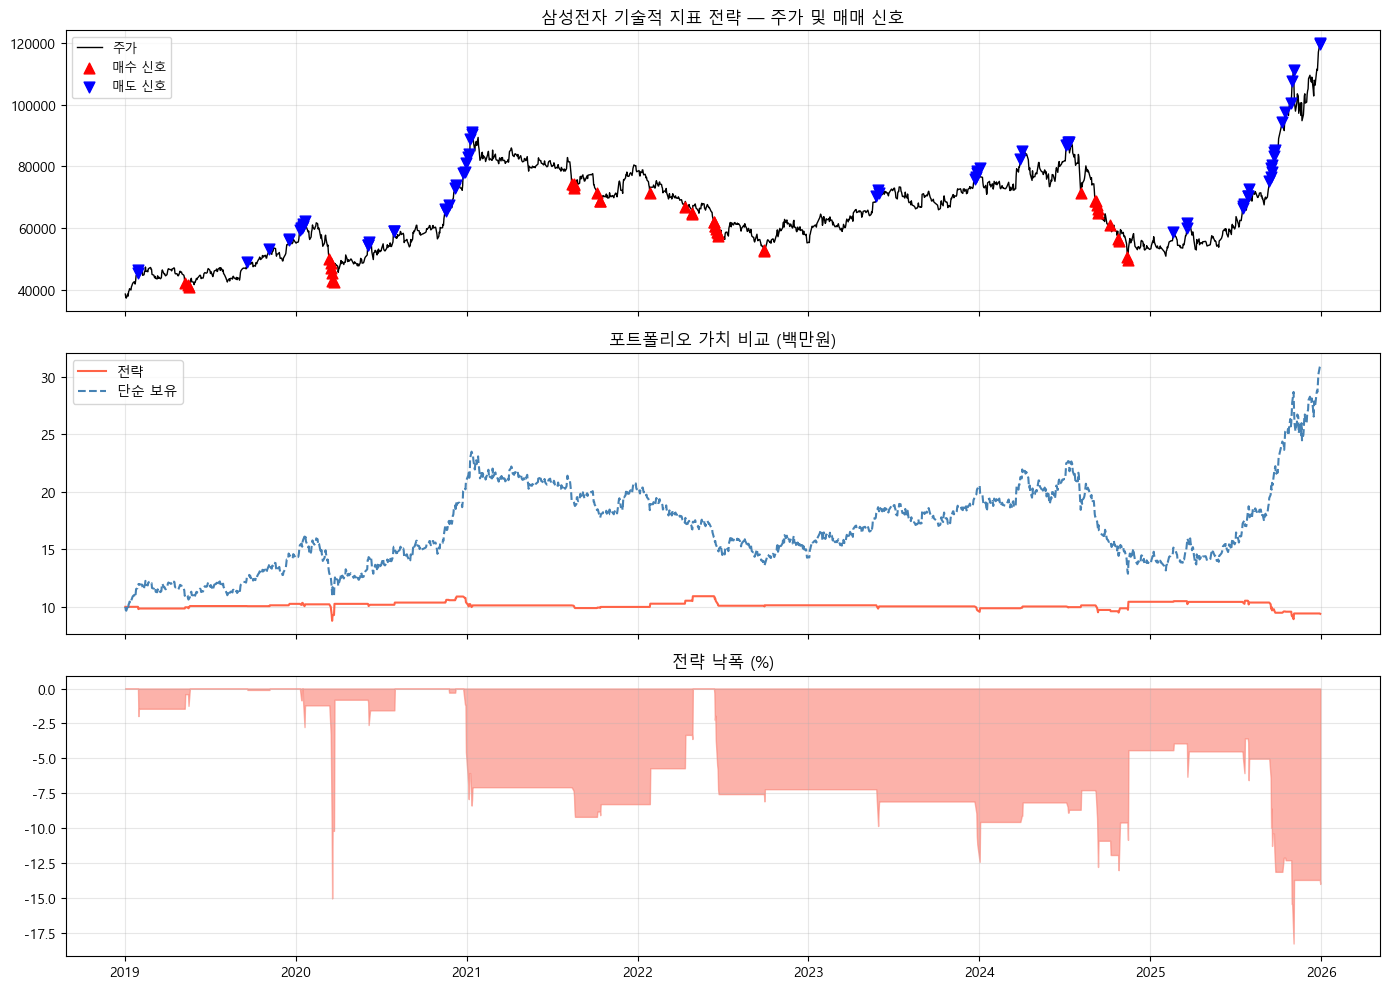

In [2]:
# ─────────────────────────────────────────
# 1단계: 삼성전자 단일 종목 백테스팅
# 기술적 전략 vs 단순 보유
# ─────────────────────────────────────────
samsung = load_stock('005930')
samsung = add_all_indicators(samsung)
signals = generate_signals(samsung)

bt = Backtester(
    prices=samsung['Close'],
    signals=signals['Final_Signal'],
    init_cash=10_000_000  # 초기 투자금 1,000만원
)
bt.run()
bt.summary()
bt.plot(title='삼성전자 기술적 지표 전략')

In [3]:
# ─────────────────────────────────────────
# 2단계: 대형주 6종목 백테스팅 비교
# ─────────────────────────────────────────
test_stocks = {
    '005930': '삼성전자',
    '000660': 'SK하이닉스',
    '005380': '현대차',
    '035420': 'NAVER',
    '035720': '카카오',
    '105560': 'KB금융',
}

all_metrics = []
for code, name in tqdm(test_stocks.items(), desc='백테스팅'):
    df = load_stock(code)
    if df is None:
        continue
    df = add_all_indicators(df)
    sigs = generate_signals(df)
    bt = Backtester(df['Close'], sigs['Final_Signal'])
    bt.run()
    m = bt.summary()
    m['종목명'] = name
    all_metrics.append(m)

metrics_df = pd.DataFrame(all_metrics).set_index('종목명')
print('\n=== 종목별 성과 비교 ===')
print(metrics_df.to_string())

백테스팅: 100%|██████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 44.01it/s]

        백테스팅 성과 요약
  전략 총수익률               : -6.1%
  단순보유 총수익률             : 209.4%
  전략 연간수익률(CAGR)        : -0.9%
  단순보유 CAGR             : 18.0%
  샤프 비율                 : -0.06
  최대 낙폭(MDD)            : -18.3%
  거래 승률                 : 40.4%
        백테스팅 성과 요약
  전략 총수익률               : 1.9%
  단순보유 총수익률             : 974.3%
  전략 연간수익률(CAGR)        : 0.3%
  단순보유 CAGR             : 41.6%
  샤프 비율                 : 0.08
  최대 낙폭(MDD)            : -31.5%
  거래 승률                 : 46.0%
        백테스팅 성과 요약
  전략 총수익률               : -27.6%
  단순보유 총수익률             : 160.1%
  전략 연간수익률(CAGR)        : -4.6%
  단순보유 CAGR             : 15.0%
  샤프 비율                 : -0.32
  최대 낙폭(MDD)            : -44.2%
  거래 승률                 : 50.0%
        백테스팅 성과 요약
  전략 총수익률               : 22.9%
  단순보유 총수익률             : 105.5%
  전략 연간수익률(CAGR)        : 3.1%
  단순보유 CAGR             : 11.1%
  샤프 비율                 : 0.35
  최대 낙폭(MDD)            : -18.3%
  거래 승률                 : 52.7%
        백테스팅 성과 요약
  전략 

In [4]:
# ─────────────────────────────────────────
# 3단계: 전 종목 기술적 전략 vs 단순 보유
# 300개 종목 샘플로 수익률 분포 비교
# ─────────────────────────────────────────
price_dir = '../data/prices'
files = [f for f in os.listdir(price_dir) if f.endswith('.parquet')][:300]

strat_rets, bh_rets = [], []

for fname in tqdm(files, desc='전 종목 백테스팅'):
    code = fname.replace('.parquet', '')
    df = load_stock(code)
    if df is None or len(df) < 300:
        continue
    try:
        df = add_all_indicators(df)
        sigs = generate_signals(df)
        bt = Backtester(df['Close'], sigs['Final_Signal'], init_cash=1_000_000)
        bt.run()
        strat_rets.append((bt.result['Portfolio'].iloc[-1] / 1_000_000 - 1) * 100)
        bh_rets.append((bt.result['Buy_Hold'].iloc[-1]  / 1_000_000 - 1) * 100)
    except Exception:
        pass

print(f'분석 완료: {len(strat_rets)}개 종목')

전 종목 백테스팅: 100%|██████████████████████████████████████████████████████████████| 300/300 [00:04<00:00, 60.09it/s]

분석 완료: 289개 종목


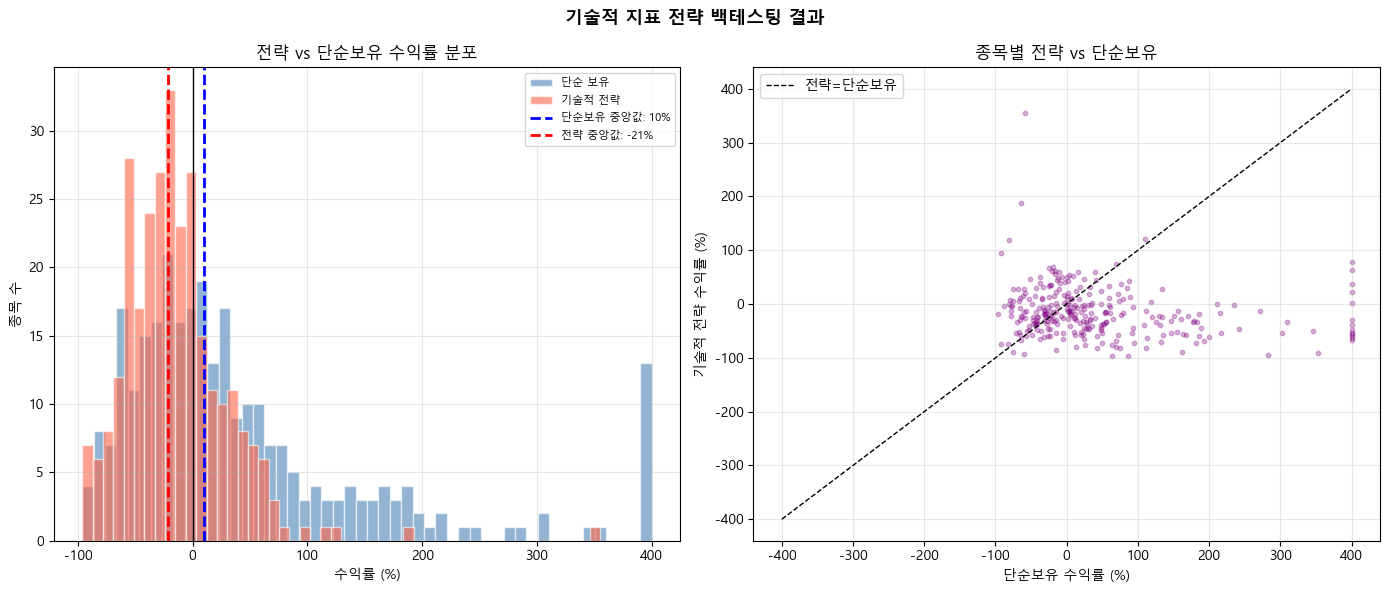

=== 전략 성과 요약 ===
                     단순 보유     기술적 전략
평균 수익률                   58.1%      -14.9%
중앙값 수익률                  10.1%      -21.1%
수익 종목 비율                57.4%      28.0%


In [5]:
# 분포 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

clip_min, clip_max = -100, 400
axes[0].hist(np.clip(bh_rets, clip_min, clip_max),
             bins=50, alpha=0.6, color='steelblue', label='단순 보유', edgecolor='white')
axes[0].hist(np.clip(strat_rets, clip_min, clip_max),
             bins=50, alpha=0.6, color='tomato', label='기술적 전략', edgecolor='white')
axes[0].axvline(np.median(bh_rets), color='blue', linestyle='--', linewidth=2,
                label=f'단순보유 중앙값: {np.median(bh_rets):.0f}%')
axes[0].axvline(np.median(strat_rets), color='red', linestyle='--', linewidth=2,
                label=f'전략 중앙값: {np.median(strat_rets):.0f}%')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('전략 vs 단순보유 수익률 분포')
axes[0].set_xlabel('수익률 (%)')
axes[0].set_ylabel('종목 수')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(np.clip(bh_rets, clip_min, clip_max),
                np.clip(strat_rets, clip_min, clip_max),
                alpha=0.3, s=10, color='purple')
lim = min(max(abs(np.array(bh_rets + strat_rets)).max(), 50), 400)
axes[1].plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='전략=단순보유')
axes[1].set_xlabel('단순보유 수익률 (%)')
axes[1].set_ylabel('기술적 전략 수익률 (%)')
axes[1].set_title('종목별 전략 vs 단순보유')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('기술적 지표 전략 백테스팅 결과', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== 전략 성과 요약 ===')
print(f'{"":20} 단순 보유     기술적 전략')
print(f'{"평균 수익률":<20} {np.mean(bh_rets):>8.1f}%   {np.mean(strat_rets):>8.1f}%')
print(f'{"중앙값 수익률":<20} {np.median(bh_rets):>8.1f}%   {np.median(strat_rets):>8.1f}%')
print(f'{"수익 종목 비율":<20} {np.mean(np.array(bh_rets)>0)*100:>7.1f}%   {np.mean(np.array(strat_rets)>0)*100:>7.1f}%')

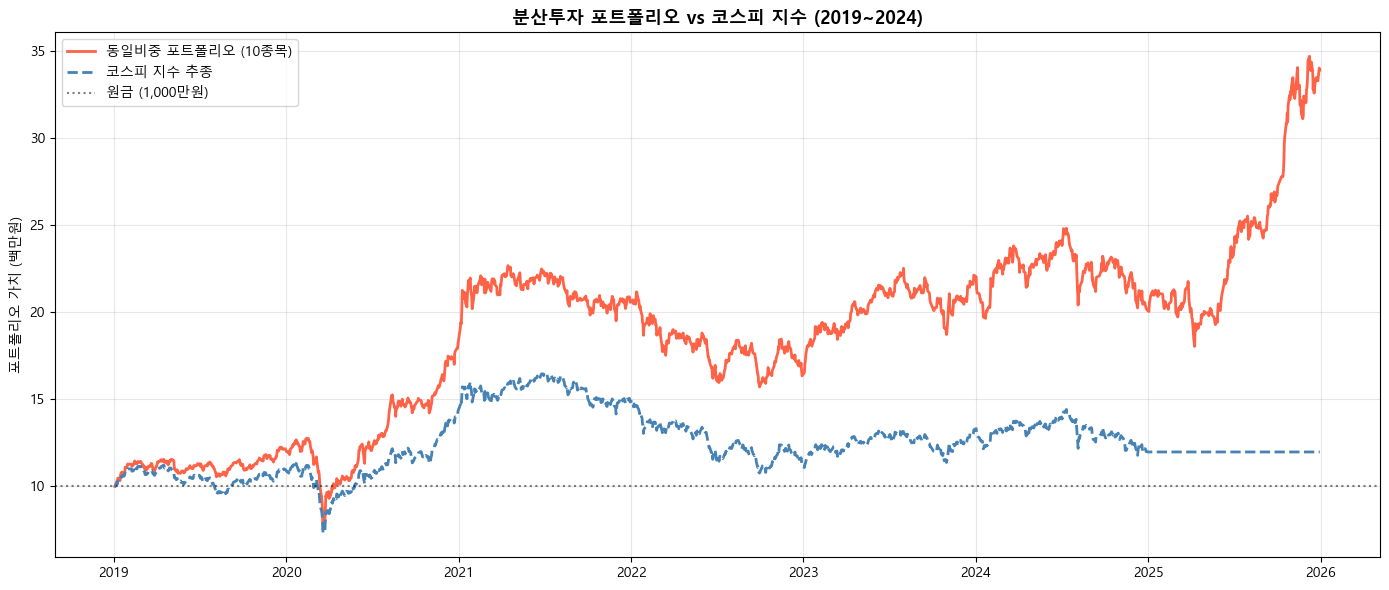

=== 포트폴리오 성과 요약 ===
                             포트폴리오    코스피
총수익률                            239.0%      19.4%
CAGR (연간수익률)                     19.6%       2.6%

모든 분석 완료!


In [6]:
# ─────────────────────────────────────────
# 4단계: 분산투자 포트폴리오 vs 코스피 지수
# ─────────────────────────────────────────
kospi = fdr.DataReader('KS11', '2019-01-01', '2024-12-31')['Close']

portfolio_codes = ['005930','000660','005380','051910',
                   '035420','105560','055550','003670','066570','012330']

port_rets = {}
for code in portfolio_codes:
    df = load_stock(code)
    if df is not None:
        port_rets[code] = df['Close'].pct_change()

port_df = pd.DataFrame(port_rets).dropna()
equal_weight_daily = port_df.mean(axis=1)  # 동일 비중 평균

init_cash = 10_000_000
port_value  = init_cash * (1 + equal_weight_daily).cumprod()
kospi_value = init_cash * (1 + kospi.pct_change().reindex(port_value.index).fillna(0)).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(port_value.index,  port_value / 1e6,
         label='동일비중 포트폴리오 (10종목)', color='tomato',    linewidth=2)
plt.plot(kospi_value.index, kospi_value / 1e6,
         label='코스피 지수 추종',             color='steelblue', linewidth=2, linestyle='--')
plt.axhline(y=init_cash/1e6, color='black', linestyle=':', alpha=0.5, label='원금 (1,000만원)')

plt.title('분산투자 포트폴리오 vs 코스피 지수 (2019~2024)', fontsize=13, fontweight='bold')
plt.ylabel('포트폴리오 가치 (백만원)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_years = len(port_value) / 252
final_port  = port_value.iloc[-1]
final_kospi = kospi_value.iloc[-1]

print('=== 포트폴리오 성과 요약 ===')
print(f'{"":28} 포트폴리오    코스피')
print(f'{"총수익률":<28} {(final_port/init_cash-1)*100:>8.1f}%  {(final_kospi/init_cash-1)*100:>8.1f}%')
print(f'{"CAGR (연간수익률)":<28} {((final_port/init_cash)**(1/n_years)-1)*100:>8.1f}%  {((final_kospi/init_cash)**(1/n_years)-1)*100:>8.1f}%')

print('\n모든 분석 완료!')